# Eddy Covariance (EC) Data Analysis with TIDBRepo Versions

This notebook illustrates the analysis workflow of eddy covariance (EC) data on TIDBRepo. The TIDBRepo URL is https://tidbrepo.usm.my. 

The code shows how to use different versions of the database programmatically. The persistent identification (PID) of the database is https://tidbrepo.usm.my/pid/0ce49c88-33dd-4b3c-9506-4c98f692e7b7.

Load Modules for DBRepo. Install the modules first.
Modules needed:
1. `dbrepo.RestClient`
2. `urllib3`

Module for dataframes:
1. `pandas`

In [1]:

from dbrepo.RestClient import RestClient
import urllib3, pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


## TIDBRepo Access Settings
The URL (endpoint) to the database is public.

In [2]:

client = RestClient(
    endpoint = "https://tidbrepo.usm.my",
    secure = False
)


## TIDBRepo Database and Table Identification

The identification can be obtained from the front end of the database under the tab, "Info".

Two identifications are needed for data retrieval:
1. Database ID
2. Table ID

The database and table identification number can also be obtained through API calls. This is demonstrated in the `ec_tidbrepo_interoperability.ipynb` notebook.

In [3]:

DB_ID = "f202bc5d-738c-41d7-b40d-a6fcd047a0ca"    #Database ID
TB_ID = "2c9b0979-4c9e-4c77-a550-0aeea9eff80d"    #Table ID


## Choosing the Version of the Data 

The default download is the latest version of the data. You can choose a previous version of data for comparative analysis.


### View Changes Timestamps (optional)
The function `get_table_history` allows you to browse the version timestamps. The code below lists the events with its timestamps and show the last ten days' events.

In [4]:

hist = client.get_table_history(database_id = DB_ID, 
                                table_id = TB_ID)

hist_df = pd.DataFrame([{ 
    "event": h.event.value if hasattr(h.event, "value") else str(h.event),
    "total": h.total,
    "timestamp": pd.to_datetime(h.timestamp)
} for h in hist]).sort_values("timestamp")

recent = hist_df[hist_df["timestamp"] >= (hist_df["timestamp"].max() - pd.Timedelta(days = 10))]


display(recent.tail(10))


,event,total,timestamp
88,delete,1,2026-03-14 01:16:17.605000+00:00
90,delete,1,2026-03-14 01:16:17.624000+00:00
92,delete,1,2026-03-14 01:16:17.624000+00:00
96,delete,1,2026-03-14 01:16:17.760000+00:00
94,delete,1,2026-03-14 01:16:17.761000+00:00
98,delete,1,2026-03-14 01:16:17.764000+00:00
22,delete,1,2026-03-14 01:19:46.418000+00:00
24,delete,1,2026-03-14 01:19:46.429000+00:00
26,delete,1,2026-03-14 01:19:46.648000+00:00
28,delete,1,2026-03-14 01:19:46.699000+00:00


### Choose a Key Timestamp

Picking a timestamp from the table history allow you to choose the before and after versions of the table. 

For example, the timestamp 2026-03-19 13:00:00 was chosen for an earlier data version, while 2026-03-14 00:00:00 for a later version of the data, after its raw data processing workflow was updated.


In [5]:

KEY_TS_AFTER = pd.Timestamp("2026-03-19 13:00:00")
KEY_TS_BEFORE = pd.Timestamp("2026-03-14 00:00:00")


## Expand Table View (optional)
The code for a full view of the table.

In [6]:

pd.set_option("display.max_columns", None) # show all columns
pd.set_option("display.width", 2000) # wider display
pd.set_option("display.max_colwidth", None) # no truncation in cells


## The Data for the After Key Timestamp

We can retrieve the data using the `get_table_data` function. The database and table identifications are needed to access it. The `timestamp` is needed when a specific version of the data is required.


### Retrieve the latest data.

In [7]:

df_latest = pd.DataFrame(
    client.get_table_data(database_id = DB_ID, 
                          table_id=TB_ID, 
                          timestamp = KEY_TS_AFTER)
)


### Show the latest data.

In [8]:

print(df_latest.shape)
df_latest.head()


(1628, 128)


,timestamp,doy,daytime,file_records,used_records,tau,qc_tau,h,qc_h,le,qc_le,co2_flux,qc_co2_flux,h2o_flux,qc_h2o_flux,h_strg,le_strg,co2_strg,h2o_strg,co2_v_adv,h2o_v_adv,co2_molar_density,co2_mole_fraction,co2_mixing_ratio,co2_time_lag,co2_def_timelag,h2o_molar_density,h2o_mole_fraction,h2o_mixing_ratio,h2o_time_lag,h2o_def_timelag,sonic_temperature,air_temperature,air_pressure,air_density,air_heat_capacity,air_molar_volume,et,water_vapor_density,e,es,specific_humidity,rh,vpd,tdew,u_unrot,v_unrot,w_unrot,u_rot,v_rot,w_rot,wind_speed,max_wind_speed,wind_dir,yaw,pitch,roll,u_,tke,l,_z_d__l,bowen_ratio,t_,model,x_peak,x_offset,x_10_,x_30_,x_50_,x_70_,x_90_,un_tau,tau_scf,un_h,h_scf,un_le,le_scf,un_co2_flux,co2_scf,un_h2o_flux,h2o_scf,spikes_hf,amplitude_resolution_hf,drop_out_hf,absolute_limits_hf,skewness_kurtosis_hf,skewness_kurtosis_sf,discontinuities_hf,discontinuities_sf,timelag_hf,timelag_sf,attack_angle_hf,non_steady_wind_hf,u_spikes,v_spikes,w_spikes,ts_spikes,co2_spikes,h2o_spikes,chopper_li_7500,detector_li_7500,pll_li_7500,sync_li_7500,mean_value_rssi_li_7500,u_var,v_var,w_var,ts_var,co2_var,h2o_var,w_ts_cov,w_co2_cov,w_h2o_cov,vin_sf_mean,co2_mean,h2o_mean,dew_point_mean,co2_signal_strength_7500_mean,loggertemp,vin_1_1_1,ppfd_1_1_1,p_rain_1_1_1,rg_1_1_1,rg_1_1_1_1,rh_1_1_1,rn_1_1_1,ta_1_1_1,ts_1_1_1
0,2026-01-31 00:30:00.0,31.0208,0,18000,18000,-0.003912,1,1.06576,1,14.5360,1.0,-0.285451,1.0,0.331464,1.0,NaN,NaN,NaN,NaN,0.0,0.0,17.3165,430.496,443.178,0.1,0.0,1226.43,30.4896,31.4484,0.0,0.0,302.371,301.212,100733.0,1.15166,1022.78,0.024860,0.021479,0.022100,3072.14,3782.73,0.019190,81.2151,710.581,297.646,0.204776,2.06366,0.019332,2.07388,0.0,0.0,2.07388,3.02250,5.73915,84.3331,0.534088,NaN,0.058283,0.081434,-16.35270,-0.243997,0.073318,-0.015524,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003870,1.01080,1.89228,1.01559,12.7197,1.09524,-0.438432,1.09524,0.290048,1.09524,800000099,800000099,800000099,800000099,800000099,800000099,899999999,899999999,89999,89999,89,89,6,3,2,0,2,1,0,0,0,0,100,0.0852,0.0770,0.0007,0.0241,0.0020,873.274,0.0016,-0.0004,0.2900,0,430.466,28.6149,23.3613,97.6781,28.4600,11.9119,0.0000,0.0,0.1039,NaN,81.2151,-44.9360,301.223,293.148
1,2026-01-31 01:00:00.0,31.0416,0,18000,18000,-0.004027,1,1.27273,1,15.4815,1.0,-0.308839,1.0,0.352988,1.0,NaN,NaN,NaN,NaN,0.0,0.0,17.2675,429.250,442.011,0.1,0.0,1230.73,30.5946,31.5602,0.0,0.0,302.297,301.110,100706.0,1.15168,1022.84,0.024859,0.022874,0.022178,3081.88,3760.38,0.019257,81.9566,678.499,297.699,0.362000,1.94162,0.019283,1.97517,0.0,0.0,1.97517,3.17575,10.57250,79.4389,0.559380,NaN,0.059134,0.090267,-14.29910,-0.279038,0.082210,-0.018271,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003983,1.01101,2.15108,1.01553,13.5311,1.09481,-0.477110,1.09481,0.308518,1.09481,800000099,800000099,800000099,800000099,800000099,800000099,899999999,899999999,89999,89999,89,89,5,1,0,1,0,0,0,0,0,0,99,0.0835,0.0963,0.0008,0.0285,0.0024,834.440,0.0018,-0.0005,0.3085,0,429.221,28.8692,23.5036,97.5671,28.3000,11.9116,0.0463,0.0,0.0978,NaN,81.9566,-45.2244,301.056,293.119
2,2026-01-31 01:30:00.0,31.0624,0,18000,18000,-0.004311,1,2.00827,1,16.9453,1.0,-0.379380,1.0,0.386202,1.0,NaN,NaN,NaN,NaN,0.0,0.0,17.2720,428.811,441.399,0.2,0.0,1221.89,30.3356,31.2847,0.0,0.0,301.834,300.679,100691.0,1.15328,1022.68,0.024827,0.025026,0.022018,3055.34,3666.83,0.019092,83.3236,611.495,297.555,0.098426,1.89291,0.021417,1.89559,0.0,0.0,1.89559,2.87894,3.09921,87.0234,0.647369,NaN,0.061143,0.103086,-10.01570,-0.398374,0.118515,-0.027849,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004264,1.01121,2.95911,1.01551,14.7350,1.09450,-0.587325,1.09450,0.335828,1.09450,800000099,800000099,800000099,800000099,800000099,800000099,899999999,899999999,89999,89999,89,89,5,2,0,1,1,1,0,0,0,0,98,0.0961,0.1094,0.0007,0.0444,0.0030,897.325,0.0025,-0.0006,0.3358,0,428.780,28.5171,23.2973,97.5310,28.0100,11.9108,-0.0069,0.0,0.0947,NaN,83.3236,-45.9200,300.654,293.074
3,2026-01-31 02:00:00.0,31.0833,0,18000,18000,-0.004664,1,2.11375,1,16.9007,1.0,

## The Data before the Key Timestamp

### Retrieve the previous data

In [9]:

df_previous = pd.DataFrame(
    client.get_table_data(database_id = DB_ID, 
                          table_id = TB_ID, 
                          timestamp = KEY_TS_BEFORE)
)




### Show the previous data

In [10]:

print(df_previous.shape)
df_previous.head()


(4676, 128)


,timestamp,doy,daytime,file_records,used_records,tau,qc_tau,h,qc_h,le,qc_le,co2_flux,qc_co2_flux,h2o_flux,qc_h2o_flux,h_strg,le_strg,co2_strg,h2o_strg,co2_v_adv,h2o_v_adv,co2_molar_density,co2_mole_fraction,co2_mixing_ratio,co2_time_lag,co2_def_timelag,h2o_molar_density,h2o_mole_fraction,h2o_mixing_ratio,h2o_time_lag,h2o_def_timelag,sonic_temperature,air_temperature,air_pressure,air_density,air_heat_capacity,air_molar_volume,et,water_vapor_density,e,es,specific_humidity,rh,vpd,tdew,u_unrot,v_unrot,w_unrot,u_rot,v_rot,w_rot,wind_speed,max_wind_speed,wind_dir,yaw,pitch,roll,u_,tke,l,_z_d__l,bowen_ratio,t_,model,x_peak,x_offset,x_10_,x_30_,x_50_,x_70_,x_90_,un_tau,tau_scf,un_h,h_scf,un_le,le_scf,un_co2_flux,co2_scf,un_h2o_flux,h2o_scf,spikes_hf,amplitude_resolution_hf,drop_out_hf,absolute_limits_hf,skewness_kurtosis_hf,skewness_kurtosis_sf,discontinuities_hf,discontinuities_sf,timelag_hf,timelag_sf,attack_angle_hf,non_steady_wind_hf,u_spikes,v_spikes,w_spikes,ts_spikes,co2_spikes,h2o_spikes,chopper_li_7500,detector_li_7500,pll_li_7500,sync_li_7500,mean_value_rssi_li_7500,u_var,v_var,w_var,ts_var,co2_var,h2o_var,w_ts_cov,w_co2_cov,w_h2o_cov,vin_sf_mean,co2_mean,h2o_mean,dew_point_mean,co2_signal_strength_7500_mean,loggertemp,vin_1_1_1,ppfd_1_1_1,p_rain_1_1_1,rg_1_1_1,rg_1_1_1_1,rh_1_1_1,rn_1_1_1,ta_1_1_1,ts_1_1_1
0,2025-12-06 19:30:00.0,340.8123,0,18000,18000,-0.000354,2,0.108558,1,NaN,-9999,NaN,-9999,NaN,-9999,None,None,None,None,NaN,0.0,NaN,NaN,NaN,NaN,1.0,1.05928,0.026131,0.026132,NaN,0.0,299.389,297.940,100411.0,1.17411,1005.70,0.024669,NaN,0.000019,2.62461,3119.17,0.000016,0.084144,3116.54,215.930,0.052945,-0.274770,-0.008333,0.279949,0.0,0.0,0.279949,0.874272,174.094,280.907,-1.70580,None,0.017355,0.019688,-4.207090,-0.948398,NaN,-0.005297,1,38.2800,17.0,30.0,49.0,73.0,115.0,254.0,-0.000339,1.04409,0.104885,1.03502,NaN,NaN,NaN,NaN,NaN,NaN,800000099,800000199,800000099,800001199,800000199,800001199,899999999,899999999,89999,89999,89,89,15,4,0,1,1,1,0,0,0,0,46,0.0279,0.0113,0.0002,0.0219,NaN,NaN,0.0001,NaN,NaN,0,1455.460,-1.5250,-28.4272,48.1900,26.19,11.8665,0.0,0.0002,0.0841,None,100.0,-39.6309,297.96,294.069
1,2025-12-06 20:00:00.0,340.8331,0,18000,18000,0.000100,2,0.102180,1,-0.556140,1,0.001610,2,-0.012640,1,None,None,None,None,0.0,0.0,26.5395,654.150,656.382,0.0,1.0,1.06651,0.026287,0.026288,-0.9,0.0,299.278,297.802,100450.0,1.17511,1005.69,0.024648,-0.000819,0.000019,2.64130,3093.51,0.000016,0.085382,3090.87,215.981,-0.004601,-0.189035,-0.008447,0.189279,0.0,0.0,0.189279,0.620115,183.107,268.606,-2.55784,None,0.009226,0.010314,-0.671612,-5.940930,-0.183730,-0.009372,1,23.7196,11.0,18.0,30.0,43.0,67.0,142.0,0.000094,1.05979,0.066782,1.04553,-0.492295,1.12969,0.001925,1.12969,-0.011189,1.12969,800000099,800000099,800000099,800000099,800000099,800000099,899999999,899999999,89999,89999,89,89,6,4,0,0,11,0,0,0,0,0,58,0.0112,0.0094,0.0001,0.0201,0.0097,1625.7000,0.0001,0.0000,-0.0112,0,654.103,3.4011,-8.5664,57.1654,26.19,11.8665,0.0,0.0002,0.0841,None,100.0,-39.6309,297.96,294.069
2,2025-12-06 20:30:00.0,340.8540,0,18000,18000,0.000264,1,0.271127,1,-0.032911,2,0.177548,1,-0.000748,2,None,None,None,None,0.0,0.0,27.0552,666.631,669.128,0.5,0.0,1.14490,0.028210,0.028211,0.0,1.0,299.248,297.819,100491.0,1.17551,1005.69,0.024640,-0.000048,0.000021,2.83562,3096.69,0.000018,0.091569,3093.86,216.551,-0.003807,-0.192005,-0.009531,0.192280,0.0,0.0,0.192280,0.594379,180.953,268.864,-2.84114,None,0.014973,0.010147,-1.082220,-3.686860,-8.238080,-0.015317,1,17.0139,8.0,13.0,21.0,32.0,49.0,106.0,0.000249,1.05908,0.257608,1.04504,-0.029183,1.12905,0.139243,1.12905,-0.000663,1.12905,800000099,800000099,800000099,800000099,800000099,800000099,899999999,899999999,89999,89999,89,89,12,0,0,0,5,5,0,0,0,0,60,0.0108,0.0094,0.0001,0.0124,0.0487,24.0503,0.0002,0.0001,-0.0007,0,666.581,3.7321,-6.5979,60.9041,26.19,11.8665,0.0,0.0002,0.0841,None,100.0,-39.6309,297.96,294.069
3,2025-12-06 21:00:00.0,340.8748,0,18000,18000,-0.000082,2,0.211536,1,-0.106208

## Reset Table View (optional)

In [11]:

pd.reset_option("display.max_columns")
pd.reset_option("display.width")
pd.reset_option("display.max_colwidth")


## Differences in LE between KEY_TS_BEFORE and KEY_TS_AFTER

### Ensure datetime.

In [12]:

df_latest["timestamp"] = pd.to_datetime(df_latest["timestamp"], errors="coerce")
df_previous["timestamp"] = pd.to_datetime(df_previous["timestamp"], errors="coerce")


### Filter for Feb 2026.

In [13]:

start = pd.Timestamp("2026-02-01 00:00:00")
end = pd.Timestamp("2026-03-01 00:00:00")


In [14]:

feb_latest = df_latest[(df_latest["timestamp"] >= start) & (df_latest["timestamp"] < end)]
feb_previous = df_previous[(df_previous["timestamp"] >= start) & (df_previous["timestamp"] < end)]


### Mean LE.

In [15]:

mean_le_latest_feb = pd.to_numeric(feb_latest["le"], errors="coerce").mean()
mean_le_previous_feb = pd.to_numeric(feb_previous["le"], errors="coerce").mean()

print("Mean LE (Feb 2026) - latest :", mean_le_latest_feb)
print("Mean LE (Feb 2026) - previous:", mean_le_previous_feb)


Mean LE (Feb 2026) - latest : 6.4972369263157885
Mean LE (Feb 2026) - previous: 6.385855013533835


## Differences in CO2 Flux between KEY_TS_BEFORE and KEY_TS_AFTER

### Ensure datetime.

In [16]:

df_latest["timestamp"] = pd.to_datetime(df_latest["timestamp"], errors="coerce")
df_previous["timestamp"] = pd.to_datetime(df_previous["timestamp"], errors="coerce")


### Filter Feb 2026.

In [17]:

start = pd.Timestamp("2026-02-01 00:00:00")
end = pd.Timestamp("2026-03-01 00:00:00")

feb_latest = df_latest[(df_latest["timestamp"] >= start) & (df_latest["timestamp"] < end)]
feb_previous = df_previous[(df_previous["timestamp"] >= start) & (df_previous["timestamp"] < end)]


### Mean LE.

In [18]:

mean_le_latest_feb = pd.to_numeric(feb_latest["co2_flux"], errors="coerce").mean()
mean_le_previous_feb = pd.to_numeric(feb_previous["co2_flux"], errors="coerce").mean()

print("Mean CO2 Flux (Feb 2026) - latest :", mean_le_latest_feb)
print("Mean CO2 Flux (Feb 2026) - previous:", mean_le_previous_feb)


Mean CO2 Flux (Feb 2026) - latest : -0.13127806702619418
Mean CO2 Flux (Feb 2026) - previous: -0.13213192989214176


## Differences in H between KEY_TS_BEFORE and KEY_TS_AFTER

### Ensure datetime.

In [19]:

df_latest["timestamp"] = pd.to_datetime(df_latest["timestamp"], errors="coerce")
df_previous["timestamp"] = pd.to_datetime(df_previous["timestamp"], errors="coerce")


### Filter Feb 2026.

In [20]:

start = pd.Timestamp("2026-02-01 00:00:00")
end = pd.Timestamp("2026-03-01 00:00:00")

feb_latest = df_latest[(df_latest["timestamp"] >= start) & (df_latest["timestamp"] < end)]
feb_previous = df_previous[(df_previous["timestamp"] >= start) & (df_previous["timestamp"] < end)]


### Mean LE.

In [21]:

mean_h_latest_feb = pd.to_numeric(feb_latest["h"], errors="coerce").mean()
mean_h_previous_feb = pd.to_numeric(feb_previous["h"], errors="coerce").mean()

print("Mean H (Feb 2026) - latest :", mean_h_latest_feb)
print("Mean H (Feb 2026) - previous:", mean_h_previous_feb)


Mean H (Feb 2026) - latest : 0.8169415811011905
Mean H (Feb 2026) - previous: 0.8207236718750001


## Timeseries Plots - LE

In [22]:
import matplotlib.pyplot as plt

In [23]:
time_col = "timestamp"
le_col = "le"

In [24]:
df_previous[time_col] = pd.to_datetime(df_previous[time_col])
df_latest[time_col] = pd.to_datetime(df_latest[time_col])

In [25]:
df_previous = df_previous.rename(columns={le_col: f"{le_col}_previous"})
df_latest = df_latest.rename(columns={le_col: f"{le_col}_latest"})

In [26]:
df_plot = pd.merge(
    df_previous,
    df_latest,
    on=time_col,
    how="outer"
).sort_values(time_col)

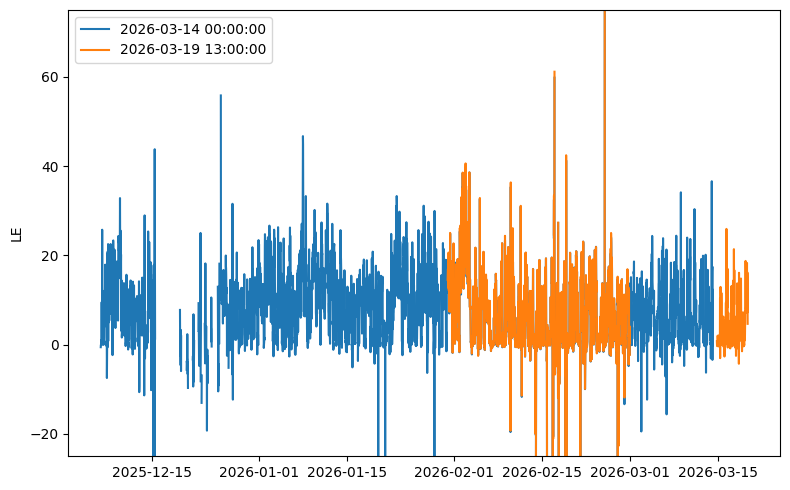

In [27]:
plt.figure(figsize=(8,5))
plt.plot(df_plot[time_col], df_plot[f"{le_col}_previous"], label = "2026-03-14 00:00:00")
plt.plot(df_plot[time_col], df_plot[f"{le_col}_latest"], label = "2026-03-19 13:00:00")
#plt.xlabel("Timestamp")
plt.ylabel("LE")
plt.ylim(-25,75)
#plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("timeseries_LE.png", dpi=300, bbox_inches="tight")
plt.show()

         
         

## Timeseries - CO2 Flux

In [28]:
time_col = "timestamp"
co2f_col = "co2_flux"

In [29]:
df_previous[time_col] = pd.to_datetime(df_previous[time_col])
df_latest[time_col] = pd.to_datetime(df_latest[time_col])

In [30]:
df_previous = df_previous.rename(columns={co2f_col: f"{co2f_col}_previous"})
df_latest = df_latest.rename(columns={co2f_col: f"{co2f_col}_latest"})

In [31]:
df_plot = pd.merge(
    df_previous,
    df_latest,
    on=time_col,
    how="outer"
).sort_values(time_col)

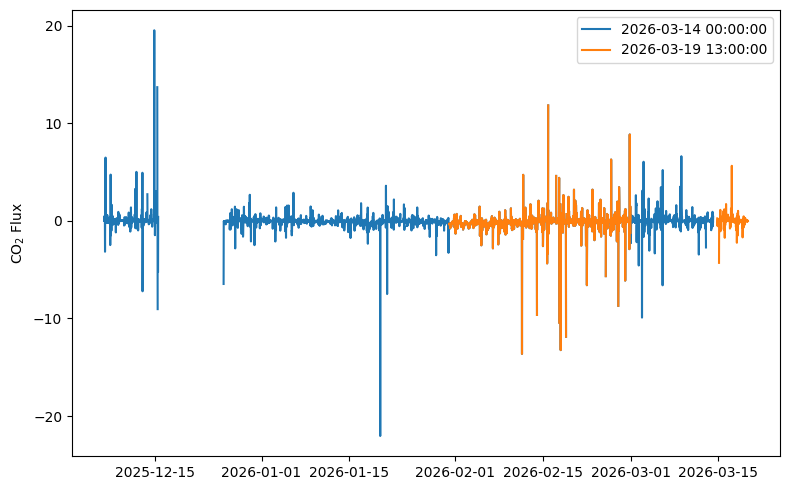

In [32]:
plt.figure(figsize=(8,5))
plt.plot(df_plot[time_col], df_plot[f"{co2f_col}_previous"], label = "2026-03-14 00:00:00")
plt.plot(df_plot[time_col], df_plot[f"{co2f_col}_latest"], label = "2026-03-19 13:00:00")
#plt.xlabel("Timestamp")
plt.ylabel("CO$_2$ Flux")
#plt.ylim(-25,75)
#plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("timeseries_co2f.png", dpi=300, bbox_inches="tight")
plt.show()